Number of columns: 140
Columns: ['nonStereoSMILES', 'descriptors', 'alcoholic', 'aldehydic', 'alliaceous', 'almond', 'amber', 'animal', 'anisic', 'apple', 'apricot', 'aromatic', 'balsamic', 'banana', 'beefy', 'bergamot', 'berry', 'bitter', 'black currant', 'brandy', 'burnt', 'buttery', 'cabbage', 'camphoreous', 'caramellic', 'cedar', 'celery', 'chamomile', 'cheesy', 'cherry', 'chocolate', 'cinnamon', 'citrus', 'clean', 'clove', 'cocoa', 'coconut', 'coffee', 'cognac', 'cooked', 'cooling', 'cortex', 'coumarinic', 'creamy', 'cucumber', 'dairy', 'dry', 'earthy', 'ethereal', 'fatty', 'fermented', 'fishy', 'floral', 'fresh', 'fruit skin', 'fruity', 'garlic', 'gassy', 'geranium', 'grape', 'grapefruit', 'grassy', 'green', 'hawthorn', 'hay', 'hazelnut', 'herbal', 'honey', 'hyacinth', 'jasmin', 'juicy', 'ketonic', 'lactonic', 'lavender', 'leafy', 'leathery', 'lemon', 'lily', 'malty', 'meaty', 'medicinal', 'melon', 'metallic', 'milky', 'mint', 'muguet', 'mushroom', 'musk', 'musty', 'natural', 'nu

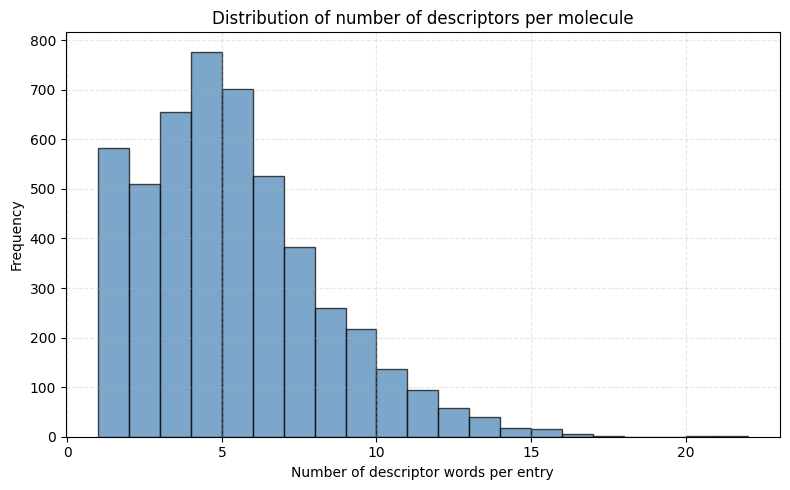

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Count the number of semicolon-separated descriptor words in 'descriptors' column
and plot their distribution.

Input file: curated_GS_LF_merged_4983.csv
"""

import pandas as pd
import matplotlib.pyplot as plt

# ──────────────── CONFIG ────────────────
IN_CSV = "curated_GS_LF_merged_4983.csv"
COLUMN = "descriptors"   # adjust if the column name differs
# ────────────────────────────────────────

# Load CSV
df = pd.read_csv(IN_CSV)

# Print number of columns and their names
print(f"Number of columns: {len(df.columns)}")
print("Columns:", list(df.columns))

# Count number of words separated by ';'
def count_descriptors(entry):
    if pd.isna(entry) or not str(entry).strip():
        return 0
    return len([x for x in str(entry).split(';') if x.strip()])

df["n_descriptors"] = df[COLUMN].apply(count_descriptors)

# Print basic stats
print("\nDescriptor count statistics:")
print(df["n_descriptors"].describe())

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(df["n_descriptors"], bins=range(1, df["n_descriptors"].max() + 2), 
         color="steelblue", edgecolor="black", alpha=0.7)
plt.xlabel("Number of descriptor words per entry")
plt.ylabel("Frequency")
plt.title("Distribution of number of descriptors per molecule")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Create a 100-row dataset sampled by descriptor-length and enriched with names.

Input : curated_GS_LF_merged_4983.csv
Output: GS_LF_rata_100.csv

Rules:
- Buckets by # of descriptor words (split on ';'): exactly 25 rows each for counts 5,4,3,2.
- SMILES from 'nonStereoSMILES'.
- compound.name_1 resolved from SMILES via PubChem (Title fallback IUPAC).
- OPTIONS = all column names except 'nonStereoSMILES' and 'descriptors'.
- question_category = 'rata'
- prompt.1 / prompt.2 embed actual values (no placeholders).
- question_ID = 1..100 in a random order (fixed seed).
- compound.name_2, SMILES_2, other_info left empty.
"""

import time
import urllib.parse
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import requests

IN_CSV  = "curated_GS_LF_merged_4983.csv"
OUT_CSV = "GS_LF_rata_100.csv"

RANDOM_SEED = 2025
TIMEOUT = 20
SLEEP   = 0.06  # polite pause between web calls

PUBCHEM_PUG = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

# ---------- helpers ----------
def count_desc(entry: object) -> int:
    """Count non-empty items split by ';'."""
    if entry is None:
        return 0
    s = str(entry)
    if not s.strip():
        return 0
    items = [x.strip() for x in s.split(";")]
    return sum(1 for x in items if x)

def ensure_columns(df: pd.DataFrame):
    needed = ["nonStereoSMILES", "descriptors"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise SystemExit(f"❌ Missing required column(s): {missing}")

def smiles_present_mask(s: pd.Series) -> pd.Series:
    return (s.astype(str)
              .str.replace("\u00A0", " ", regex=False)
              .str.strip()
              .replace({"": np.nan, "NA": np.nan, "NaN": np.nan, "null": np.nan, "None": np.nan})
              .notna())

def build_options_column_names(columns: List[str]) -> str:
    """All column names except these two, joined by '; '."""
    ex = {"nonStereoSMILES", "descriptors"}
    kept = [c for c in columns if c not in ex]
    return "; ".join(kept)

# ---------- PubChem name lookup (SMILES -> Title/IUPAC) ----------
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "SMILES-to-Name/1.0 (local-script)"})

def name_from_smiles(smiles: str) -> Tuple[Optional[str], str]:
    """
    Query PubChem: /compound/smiles/{smiles}/property/Title,IUPACName
    Returns (name, note) where name = Title or IUPACName; note is diagnostic.
    """
    if not smiles:
        return None, "empty-smiles"
    url = (f"{PUBCHEM_PUG}/compound/smiles/"
           f"{urllib.parse.quote(smiles)}/property/Title,IUPACName/JSON")
    try:
        r = SESSION.get(url, timeout=TIMEOUT)
        if r.status_code != 200:
            return None, f"http{r.status_code}"
        j = r.json()
        props = j.get("PropertyTable", {}).get("Properties", [])
        if not props:
            return None, "no-props"
        p = props[0]
        title = (p.get("Title") or "").strip() or None
        iupac = (p.get("IUPACName") or "").strip() or None
        nm = title or iupac
        return nm, ("title" if title else ("iupac" if iupac else "none"))
    except requests.RequestException as e:
        return None, f"err:{e.__class__.__name__}"
    except ValueError:
        return None, "json-decode"

def map_names_for_smiles(smiles_list: List[str]) -> Dict[str, str]:
    """
    Resolve names for unique SMILES with caching; returns {smiles: name or ''}.
    """
    unique = sorted(set([s for s in smiles_list if isinstance(s, str) and s.strip()]))
    out: Dict[str, str] = {}
    for i, smi in enumerate(unique, start=1):
        name, note = name_from_smiles(smi)
        out[smi] = name or ""
        print(f"[name {i}/{len(unique)}] SMILES→Name: {'OK' if name else 'MISS'} | {note}")
        time.sleep(SLEEP)
    return out

# ---------- main ----------
def main():
    rng = np.random.default_rng(RANDOM_SEED)

    df = pd.read_csv(IN_CSV)
    ensure_columns(df)

    # Keep only rows with a present nonStereoSMILES and non-empty descriptors
    mask_smiles = smiles_present_mask(df["nonStereoSMILES"])
    mask_desc   = df["descriptors"].astype(str).str.strip().ne("")
    df = df.loc[mask_smiles & mask_desc].copy()
    if df.empty:
        raise SystemExit("❌ No usable rows after filtering for SMILES + descriptors.")

    # Count descriptor words: we need 25 each for counts = 5,4,3,2
    df["desc_count"] = df["descriptors"].apply(count_desc)

    needs = {5: 25, 4: 25, 3: 25, 2: 25}
    picks: List[pd.DataFrame] = []

    for k, need in needs.items():
        pool = df.loc[df["desc_count"] == k]
        if len(pool) < need:
            raise SystemExit(f"❌ Need {need} rows with {k} descriptor words, but found {len(pool)}.")
        # sample without replacement with fixed seed
        picks.append(pool.sample(n=need, replace=False,
                                 random_state=int(rng.integers(0, 2**31-1))))

    selected = pd.concat(picks, ignore_index=True)

    # Resolve compound.name_1 from nonStereoSMILES via PubChem (unique SMILES only)
    name_map = map_names_for_smiles(selected["nonStereoSMILES"].astype(str).tolist())
    selected["compound.name_1"] = selected["nonStereoSMILES"].astype(str).map(lambda s: name_map.get(s, ""))

    # Build OPTIONS string (same for all rows)
    options_val = build_options_column_names(list(df.columns))

    # Assemble output frame with requested columns
    out = pd.DataFrame({
        "compound.name_1": selected["compound.name_1"].fillna(""),
        "SMILES_1": selected["nonStereoSMILES"].astype(str),
        "compound.name_2": "",     # left empty
        "SMILES_2": "",            # left empty
        "OPTIONS": options_val,
        "question_category": "rata",
        "answer": selected["descriptors"].astype(str),
        "other_info": "",          # left empty
    })

    # Create prompts with actual values (row-wise)
    def p1(row):
        return (f"Which of the following odor descriptors apply to the molecule {row['SMILES_1']}? "
                f"Select all that apply from [{row['OPTIONS']}]. Do not write any comments.")
    def p2(row):
        name = row['compound.name_1'] if row['compound.name_1'] else "this compound"
        return (f"Which of the following odor descriptors apply to the molecule {name}? "
                f"Select all that apply from [{row['OPTIONS']}]. Do not write any comments.")

    out["prompt.1"] = out.apply(p1, axis=1)
    out["prompt.2"] = out.apply(p2, axis=1)

    # Order columns exactly as requested
    out = out[[
        "compound.name_1","SMILES_1",
        "compound.name_2","SMILES_2",
        "OPTIONS","question_category","prompt.1","prompt.2","answer","other_info"
    ]]

    # Randomize row order and assign question_ID = 1..N
    out = out.sample(frac=1.0, replace=False, random_state=int(rng.integers(0, 2**31-1))).reset_index(drop=True)
    out.insert(0, "question_ID", np.arange(1, len(out) + 1, dtype=int))

    # Save
    out.to_csv(OUT_CSV, index=False)
    print(f"✅ Wrote {OUT_CSV} with {len(out)} rows "
          f"(25 each for descriptor counts 5,4,3,2).")

if __name__ == "__main__":
    main()


[name 1/100] SMILES→Name: OK | title
[name 2/100] SMILES→Name: OK | title
[name 3/100] SMILES→Name: OK | title
[name 4/100] SMILES→Name: OK | title
[name 5/100] SMILES→Name: OK | title
[name 6/100] SMILES→Name: OK | title
[name 7/100] SMILES→Name: OK | title
[name 8/100] SMILES→Name: OK | title
[name 9/100] SMILES→Name: OK | title
[name 10/100] SMILES→Name: OK | title
[name 11/100] SMILES→Name: OK | title
[name 12/100] SMILES→Name: OK | title
[name 13/100] SMILES→Name: OK | title
[name 14/100] SMILES→Name: OK | title
[name 15/100] SMILES→Name: OK | title
[name 16/100] SMILES→Name: OK | title
[name 17/100] SMILES→Name: OK | title
[name 18/100] SMILES→Name: OK | title
[name 19/100] SMILES→Name: OK | title
[name 20/100] SMILES→Name: OK | title
[name 21/100] SMILES→Name: OK | title
[name 22/100] SMILES→Name: OK | title
[name 23/100] SMILES→Name: OK | title
[name 24/100] SMILES→Name: OK | title
[name 25/100] SMILES→Name: OK | title
[name 26/100] SMILES→Name: OK | title
[name 27/100] SMILES→

Descriptive statistics for number of words in 'answer':
count    100.000000
mean       3.500000
std        1.123666
min        2.000000
25%        2.750000
50%        3.500000
75%        4.250000
max        5.000000
Name: answer_word_count, dtype: float64
✅ Saved histogram to answer_wordcount_distribution.png


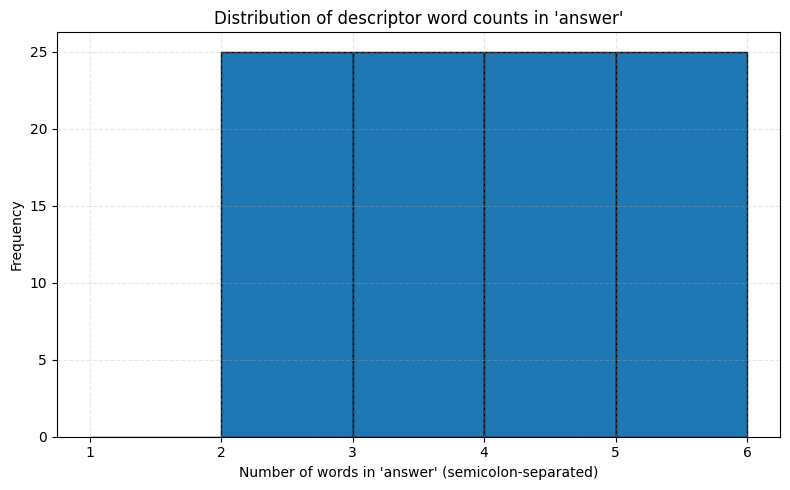

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Read curated_GS_LF_rata_100.csv and plot the distribution of the number of
semicolon-separated words in the 'answer' column.
"""

import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "GS_LF_rata_100.csv"
ANSWER_COL = "answer"   # adjust if needed

def count_semicolon_words(val) -> int:
    """Count non-empty tokens split by ';' after stripping whitespace."""
    if pd.isna(val):
        return 0
    s = str(val).replace("\u00A0", " ").strip()
    if not s:
        return 0
    tokens = [t.strip() for t in s.split(";")]
    return sum(1 for t in tokens if t)

def main():
    df = pd.read_csv(IN_CSV)

    if ANSWER_COL not in df.columns:
        raise SystemExit(f"❌ Column '{ANSWER_COL}' not found. Available: {list(df.columns)}")

    df["answer_word_count"] = df[ANSWER_COL].apply(count_semicolon_words)

    # Print quick stats
    print("Descriptive statistics for number of words in 'answer':")
    print(df["answer_word_count"].describe())

    # Build histogram bins from 1..max (skip 0 unless present)
    wc = df["answer_word_count"]
    if wc.max() >= 1:
        bins = range(1, int(wc.max()) + 2)
        plot_vals = wc[wc >= 1]
    else:
        # corner case: all zeros
        bins = [0, 1]
        plot_vals = wc

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(plot_vals, bins=bins, edgecolor="black")
    plt.xlabel("Number of words in 'answer' (semicolon-separated)")
    plt.ylabel("Frequency")
    plt.title("Distribution of descriptor word counts in 'answer'")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()

    plt.show()

if __name__ == "__main__":
    main()
